Esse desafio representa algo

In [80]:
#Imports

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

%matplotlib inline

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2",
    font_scale=1.05,
)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

STATUS_PALETTE = {
    "PASS": "#2E7D32",
    "FAIL": "#C62828",
    "REWORK": "#F9A825",
    "SCRAP": "#6A1B9A",
}

In [81]:
dataset = pd.read_excel('../Data/recording_test_setupbox.xlsx')

In [82]:
dataset.head()

,timestamp,date,time,shift,line,station,jig_id,operator,model,sku,wifi_band,has_bluetooth,has_cable,firmware_version,serial_number,mac_address,api_key,attempt,fw_download_ok,fw_download_cycle_s,fw_download_md5,bootloader_ok,bootloader_cycle_s,bootloader_md5,kernel_ok,kernel_cycle_s,kernel_md5,rootfs_ok,rootfs_cycle_s,rootfs_md5,secure_boot_ok,secure_boot_cycle_s,secure_boot_md5,mac_write_ok,mac_write_cycle_s,mac_write_md5,wifi_cal_ok,wifi_cal_cycle_s,wifi_cal_md5,bluetooth_ok,bluetooth_cycle_s,bluetooth_md5,cable_scan_ok,cable_scan_cycle_s,cable_scan_md5,hdmi_edid_ok,hdmi_edid_cycle_s,hdmi_edid_md5,dvb_tuner_ok,dvb_tuner_cycle_s,dvb_tuner_md5,drm_keys_ok,drm_keys_cycle_s,drm_keys_md5,final_check_ok,final_check_cycle_s,final_check_md5,cable_channels_found,total_cycle_s,result,failed_step,error_code,disposition
0,2022-09-12 06:00:06,2022-09-12,06:00:06,A,L2,L2-ST1,JIG-L2-ST1-2,OP-L2-A2,STB-300,LG-STB-300-5BC3,5GHz,True,True,v4.1.2,SN300220912083468,AC:5A:14:FB:E9:2B,RKEY-05B595FC92,1,True,12.80,8f9c832283bc6fa931da2c68e66da06c,True,7.60,e5e889166685aae9ea816fbd4b52e319,True,27.70,d0af4a614682e7bee95182bec5477298,True,38.40,630aee2328d502b6a8342c49610f3438,True,6.60,52bce2e22e945dc897f72eb4951871d5,True,3.80,f96ef125d029674df8000b867fa45c1a,True,33.30,8dd4ec9223c6b2684350790a6962dd38,1.00,15.60,27b5b9be5427a5a3b0b35e96df4330bd,1.00,35.10,21b28496b3d5e5389f4837847c2babe7,True,7.70,bebe4eee67d261bf493caeabd88b676f,True,18.30,92434477b026a09bf82617fda8edfe1c,True,10.10,8a8d71ffe52ed418e18205e1b08ffe99,True,5.20,7d761ebaf0435d3a4145fba0f02e32df,124.00,222.20,PASS,NaN,NaN,PASS
1,2022-09-12 06:00:07,2022-09-12,06:00:07,A,L1,L1-ST1,JIG-L1-ST1-1,OP-L1-A2,STB-100,LG-STB-100-2401,2.4GHz,False,False,v4.1.2,SN100220912073344,AC:5A:14:67:01:4C,RKEY-1AA670E63C,1,True,9.90,0d9346909082cbf9be11d3b7d4f2dc6c,True,8.80,f4d35c18a8c9a087421007f6b127780b,True,23.90,775e499985711c57608ac7ca210cc7e6,True,41.50,29329042173e587145f6e319f5481a31,True,6.00,19711710751177200ed1e3623ea6cb87,True,3.70,51bdcaad241d88e4c20069e85544c526,True,26.80,7c5ae2c9ee045a955dbf956a22b20165,NaN,NaN,NaN,NaN,NaN,NaN,True,7.20,1d45998b38268cadb47559c03e2dd0ef,True,15.80,91f9285bc19f6bf39fb8e01da1dc948e,True,8.90,a41d8f6bc155e6fbc73a07596c1556a2,True,4.50,0b308b6e810da8624459a91eb154c4e7,NaN,157.00,PASS,NaN,NaN,PASS
2,2022-09-12 06:00:41,2022-09-12,06:00:41,A,L2,L2-ST2,JIG-L2-ST2-2,OP-L2-A1,STB-300,LG-STB-300-5BC3,5GHz,True,True,v4.1.2,SN300220912073087,AC:5A:14:DB:76:1E,RKEY-05B595FC92,1,True,11.90,8f9c832283bc6fa931da2c68e66da06c,True,8.20,e5e889166685aae9ea816fbd4b52e319,True,25.00,d0af4a614682e7bee95182bec5477298,True,39.30,630aee2328d502b6a8342c49610f3438,True,6.50,52bce2e22e945dc897f72eb4951871d5,True,4.10,f96ef125d029674df8000b867fa45c1a,True,27.20,8dd4ec9223c6b2684350790a6962dd38,1.00,15.10,27b5b9be5427a5a3b0b35e96df4330bd,1.00,34.70,21b28496b3d5e5389f4837847c2babe7,True,8.40,bebe4eee67d261bf493caeabd88b676f,True,18.10,92434477b026a09bf82617fda8edfe1c,True,8.10,8a8d71ffe52ed418e18205e1b08ffe99,True,5.00,7d761ebaf0435d3a4145fba0f02e32df,126.00,211.60,PASS,NaN,NaN,PASS
3,2022-09-12 06:01:00,2022-09-12,06:01:00,A,L3,L3-ST2,JIG-L3-ST2-1,OP-L3-A2,STB-200,LG-STB-200-5C02,5GHz,False,True,v4.1.2,SN200220912078449,AC:5A:14:69:DD:B6,RKEY-1999061AD6,1,True,13.00,6050b8067d8bc1b16e6be2a078bc37ae,True,7.80,8f5d6101ddfaa62ae36d609073bc6129,True,24.20,0ef0c57946f8050913763c42d10ef2d9,True,38.10,c0679c6229a1372eab671da68f8dca30,True,5.60,3fb781d5d811a31931c68de2cd0e503c,True,3.80,431535d30c8c835c83975a7504fd5fcd,True,32.80,2e2714ad8c8808b8586f6505c5a23169,NaN,NaN,NaN,1.00,31.70,9370d8768535fa77c959078d8ccd7379,True,8.10,f89660499ce56b81f0a4ff767fe2637c,True,16.00,858037ddc1424fcb24cb85aa5028c778,True,9.70,d5efb1054f9129510bb384635bcef647,True,5.10,ff6e7d9b01c0fc8635391957a783a2a9,177.00,195.90,PASS,NaN,NaN,PASS
4,2022-09-12 06:01:14,2022-09-12,06:01:14,A,L4,L4-ST1,JIG-L4-ST1-1,OP-L4-A1,STB-400,LG-STB-400-5BC4,5GHz,True,True,v4.1.2,SN400220912079140,AC:5A:14:65:6C:6D,RKEY-2742E4DF18,1,T

In [83]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 17844 entries, 0 to 17843
Data columns (total 63 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             17844 non-null  str    
 1   date                  17844 non-null  str    
 2   time                  17844 non-null  str    
 3   shift                 17844 non-null  str    
 4   line                  17844 non-null  str    
 5   station               17844 non-null  str    
 6   jig_id                17844 non-null  str    
 7   operator              17844 non-null  str    
 8   model                 17844 non-null  str    
 9   sku                   17844 non-null  str    
 10  wifi_band             17844 non-null  str    
 11  has_bluetooth         17844 non-null  bool   
 12  has_cable             17844 non-null  bool   
 13  firmware_version      17844 non-null  str    
 14  serial_number         17844 non-null  str    
 15  mac_address           17844 no

Estatística Descritiva e Limpeza

In [84]:
dataset.describe()

,attempt,fw_download_cycle_s,bootloader_cycle_s,kernel_cycle_s,rootfs_cycle_s,secure_boot_cycle_s,mac_write_cycle_s,wifi_cal_cycle_s,bluetooth_ok,bluetooth_cycle_s,cable_scan_ok,cable_scan_cycle_s,hdmi_edid_cycle_s,dvb_tuner_cycle_s,drm_keys_cycle_s,final_check_cycle_s,cable_channels_found,total_cycle_s
count,"17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","17,844.00","7,026.00","7,026.00","12,263.00","12,263.00","17,844.00","17,844.00","17,844.00","17,844.00","12,263.00","17,844.00"
mean,1.10,12.16,8.08,26.44,40.40,6.07,4.04,30.97,0.99,16.19,0.99,35.32,8.11,18.26,10.16,5.09,151.85,200.42
std,0.30,2.91,1.68,6.68,8.50,1.28,0.82,8.03,0.08,3.53,0.09,7.17,1.98,4.44,2.62,1.41,21.74,27.31
min,1.00,8.00,5.30,16.80,27.70,4.00,2.70,20.80,0.00,11.40,0.00,24.80,5.10,12.40,6.50,3.40,0.00,148.60
25%,1.00,11.30,7.60,24.60,37.80,5.70,3.80,28.40,1.00,15.10,1.00,33.00,7.60,17.00,9.50,4.70,136.00,172.00
50%,1.00,12.00,8.00,26.00,40.00,6.00,4.00,30.10,1.00,16.00,1.00,35.00,8.00,18.00,10.00,5.00,153.00,204.70
75%,1.00,12.60,8.40,27.40,42.20,6.30,4.20,31.80,1.00,16.90,1.00,36.90,8.40,19.00,10.50,5.30,169.00,217.30
max,2.00,83.10,49.80,164.70,262.30,34.70,23.30,193.80,1.00,102.40,1.00,225.90,53.80,124.40,66.10,34.10,185.00,444.30


In [85]:
#Verificando se existem valores ausentes

dataset.isnull().sum()

timestamp                   0
date                        0
time                        0
shift                       0
line                        0
station                     0
jig_id                      0
operator                    0
model                       0
sku                         0
wifi_band                   0
has_bluetooth               0
has_cable                   0
firmware_version            0
serial_number               0
mac_address                 0
api_key                     0
attempt                     0
fw_download_ok              0
fw_download_cycle_s         0
fw_download_md5             0
bootloader_ok               0
bootloader_cycle_s          0
bootloader_md5              0
kernel_ok                   0
kernel_cycle_s              0
kernel_md5                  0
rootfs_ok                   0
rootfs_cycle_s              0
rootfs_md5                  0
secure_boot_ok              0
secure_boot_cycle_s         0
secure_boot_md5             0
mac_write_

Existem dados faltando para duas colunas, ambas equivalentes, But Why?

In [86]:
dataset.select_dtypes(include=['str']).nunique()

timestamp           16965
date                    3
time                15366
shift                   2
line                    4
station                 8
jig_id                 16
operator               16
model                   4
sku                     4
wifi_band               2
firmware_version        2
serial_number       16115
mac_address         16066
api_key                12
fw_download_md5       247
bootloader_md5         66
kernel_md5             91
rootfs_md5            636
secure_boot_md5        82
mac_write_md5          77
wifi_cal_md5          111
bluetooth_md5          45
cable_scan_md5        114
hdmi_edid_md5          89
dvb_tuner_md5          96
drm_keys_md5          703
final_check_md5        89
result                  2
failed_step            13
error_code             11
disposition             3
dtype: int64

As colunas time, serial number e mac adress possuem muitos valores unicos, possivlmente o fenomeno representado poder ser representado temporalmente

Variaveis categoricas com algum valor para analise: shift, line, station, model, sku, wifi_band, firmware_version, result, disposition. (Usar graficos de contagem)

Sobre o processo em si, Existem 16 Operadores e 16 dispositivos de testes (Esses troços de "jigs") operando o sistema, e sao pelo menos 13 ETAPAS de falha mapeadas.

Variaveis de interesse pra entender o processo: jig_id, operador, api_key, failed_step, error_code

Variavesi dos testes: roottfs_md5, fw_download_md5, cable_scan_md5 - guardam as configuracoes de hardwware testadas de forma unica (hashes).

# EDA

### Entendendo a concetraçao de falhas

### Distribuição de Pareto

Objetivo: identificar os poucos defeitos que concentram a maior parte das falhas e priorizar o que investigar primeiro.

In [87]:
failures = dataset.loc[dataset["result"].eq("FAIL")].copy()

print(f"Total de tentativas: {len(dataset):,}")
print(f"Total de falhas: {len(failures):,}")
print(f"Taxa de falha: {len(failures) / len(dataset):.2%}")

Total de tentativas: 17,844
Total de falhas: 2,296
Taxa de falha: 12.87%


In [88]:
def build_pareto(df, column):
    pareto = (
        df[column]
        .dropna()
        .value_counts()
        .rename_axis(column)
        .reset_index(name="count")
    )
    pareto["pct"] = pareto["count"] / pareto["count"].sum()
    pareto["cum_pct"] = pareto["pct"].cumsum()
    return pareto


def plot_pareto(df, column, title, ax):
    pareto = build_pareto(df, column)

    sns.barplot(
        data=pareto,
        x=column,
        y="count",
        ax=ax,
        color="#4C78A8",
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Quantidade de falhas")
    ax.tick_params(axis="x", rotation=45)
    ax.bar_label(ax.containers[0], padding=3, fontsize=8)

    ax2 = ax.twinx()
    ax2.plot(
        pareto[column],
        pareto["cum_pct"] * 100,
        color="#C62828",
        marker="o",
        linewidth=2,
    )
    ax2.axhline(80, color="#616161", linestyle="--", linewidth=1)
    ax2.set_ylim(0, 105)
    ax2.set_ylabel("Percentual acumulado")
    ax2.yaxis.set_major_formatter(PercentFormatter())

    return pareto

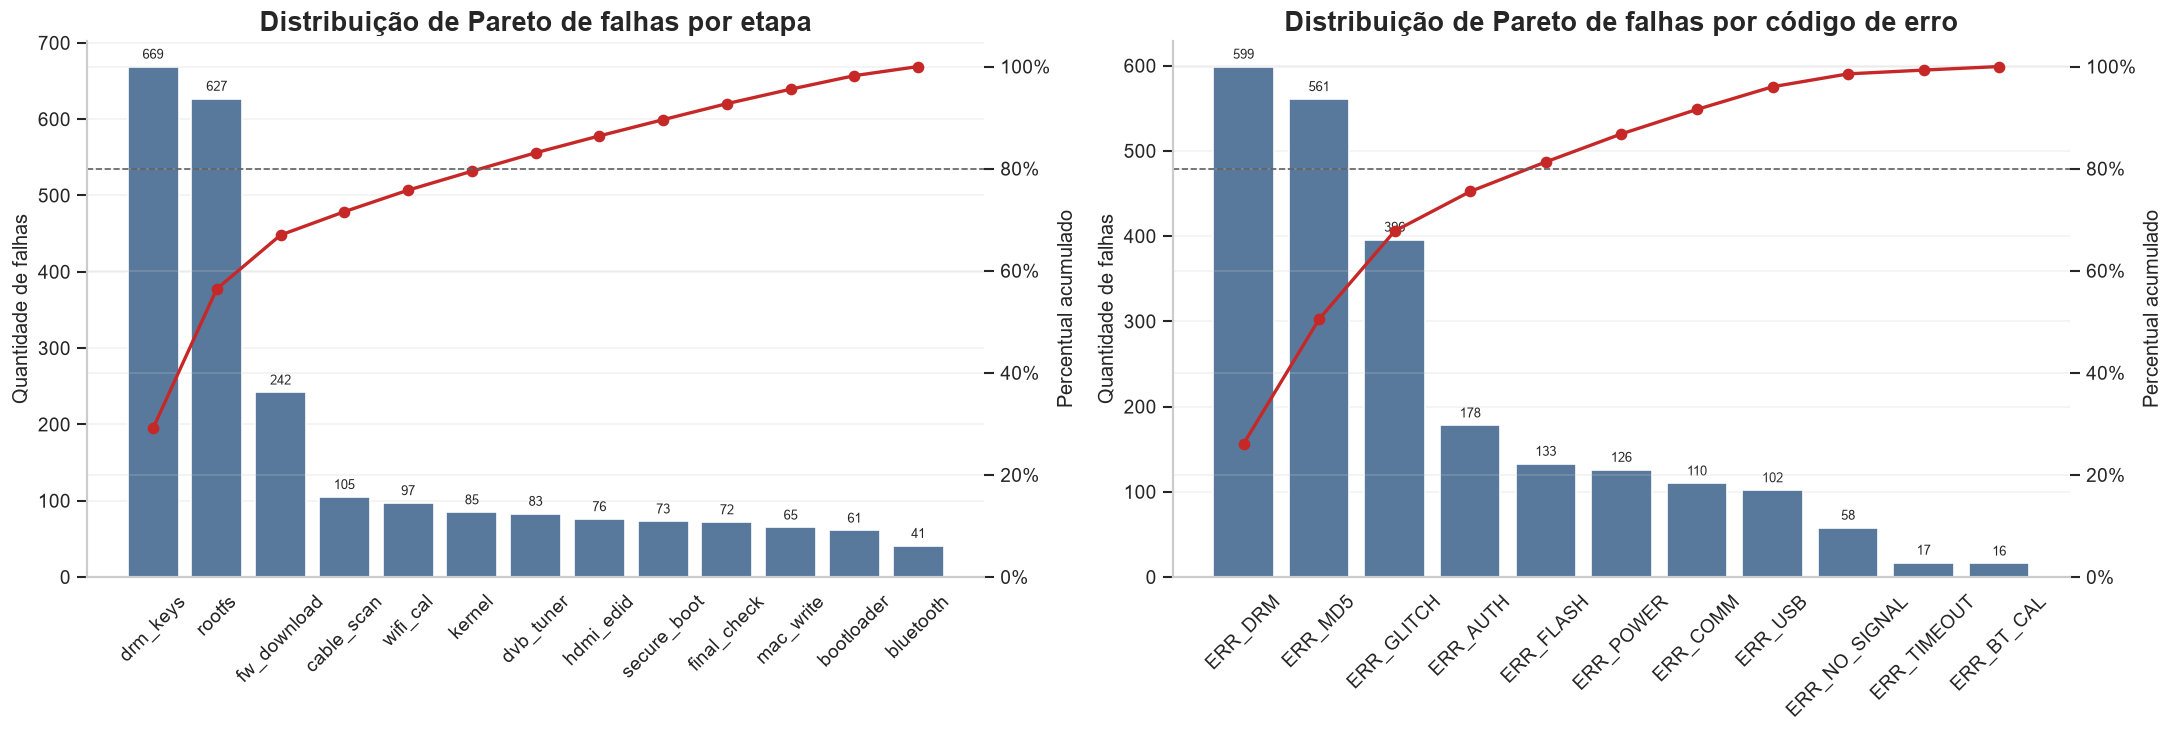

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

pareto_failed_step = plot_pareto(
    failures,
    "failed_step",
    "Distribuição de Pareto de falhas por etapa",
    axes[0],
)

pareto_error_code = plot_pareto(
    failures,
    "error_code",
    "Distribuição de Pareto de falhas por código de erro",
    axes[1],
)

plt.show()

In [90]:
pareto_failed_step_display = pareto_failed_step.copy()
pareto_failed_step_display["pct"] = (pareto_failed_step_display["pct"] * 100).map("{:.2f}%".format)
pareto_failed_step_display["cum_pct"] = (pareto_failed_step_display["cum_pct"] * 100).map("{:.2f}%".format)

pareto_error_code_display = pareto_error_code.copy()
pareto_error_code_display["pct"] = (pareto_error_code_display["pct"] * 100).map("{:.2f}%".format)
pareto_error_code_display["cum_pct"] = (pareto_error_code_display["cum_pct"] * 100).map("{:.2f}%".format)

display(pareto_failed_step_display)
display(pareto_error_code_display)

,failed_step,count,pct,cum_pct
0,drm_keys,669,29.14%,29.14%
1,rootfs,627,27.31%,56.45%
2,fw_download,242,10.54%,66.99%
3,cable_scan,105,4.57%,71.56%
4,wifi_cal,97,4.22%,75.78%
5,kernel,85,3.70%,79.49%
6,dvb_tuner,83,3.61%,83.10%
7,hdmi_edid,76,3.31%,86.41%
8,secure_boot,73,3.18%,89.59%
9,final_check,72,3.14%,92.73%


,error_code,count,pct,cum_pct
0,ERR_DRM,599,26.09%,26.09%
1,ERR_MD5,561,24.43%,50.52%
2,ERR_GLITCH,396,17.25%,67.77%
3,ERR_AUTH,178,7.75%,75.52%
4,ERR_FLASH,133,5.79%,81.32%
5,ERR_POWER,126,5.49%,86.80%
6,ERR_COMM,110,4.79%,91.59%
7,ERR_USB,102,4.44%,96.04%
8,ERR_NO_SIGNAL,58,2.53%,98.56%
9,ERR_TIMEOUT,17,0.74%,99.30%


12% das ocorrencias sao falhas, destas, a maior parte de concentra em erros de drm_keys com 29,14% desses erros, rootfs representa 27,31% dos erros, fw_download 10,54%. Esses 3 sozinhos representam 66,99% de todas as falhas, 2/3 dos defeitos registrados. Ou seja, esses 3 tipos de erros devem ser os primeiros a serem solucionados.

No caso do codigo de erro, ERR_DRM representa 26,09%, ERR_MD5 representa 24,43% dos erros e ERR_Glith representa 17,25%. Somados eles tambem sao quase 2/3 desses erros. Resumidanemente, a investigacao tem que correr primeiro por rm_keys/ERR_DRM, rootfs/ERR_MD5 e fw_download/ERR_AUTH, pois esses grupos explicam a maior parte dos defeitos e provavelmente indicam problemas sistemáticos no processo em sí.

## Recorte do defeito principal: drm_keys / ERR_DRM

Objetivo - fatiar o defeito principal para responder: onde acontece, quando acontece e qual e o impacto por linha/jig.

In [91]:
analysis_df = dataset.copy()
analysis_df["timestamp"] = pd.to_datetime(analysis_df["timestamp"])
analysis_df["is_fail"] = analysis_df["result"].eq("FAIL")

MAIN_FAILED_STEP = "drm_keys"
MAIN_ERROR_CODE = "ERR_DRM"

analysis_df["is_main_defect"] = (
    analysis_df["failed_step"].eq(MAIN_FAILED_STEP)
    | analysis_df["error_code"].eq(MAIN_ERROR_CODE)
)

main_defect = analysis_df.loc[analysis_df["is_main_defect"]].copy()

print(f"Defeito analisado: {MAIN_FAILED_STEP} / {MAIN_ERROR_CODE}")
print(f"Ocorrencias do defeito: {len(main_defect):,}")
print(f"Participacao nas falhas: {len(main_defect) / analysis_df['is_fail'].sum():.2%}")
print(f"Participacao no total de tentativas: {len(main_defect) / len(analysis_df):.2%}")
print(f"Primeira ocorrencia: {main_defect['timestamp'].min()}")
print(f"Ultima ocorrencia: {main_defect['timestamp'].max()}")

Defeito analisado: drm_keys / ERR_DRM
Ocorrencias do defeito: 669
Participacao nas falhas: 29.14%
Participacao no total de tentativas: 3.75%
Primeira ocorrencia: 2022-09-12 06:05:07
Ultima ocorrencia: 2022-09-14 21:32:47


O defeito drm_keys / ERR_DRM tem 669 ocorrencias, representando 29,14% de todas as falhas e 3,75% de todas as tentativas. Esse sozinho representa 1/3 das ocorrencias.

In [92]:
def defect_summary_by(df, dimension):
    summary = (
        df.groupby(dimension, dropna=False)
        .agg(
            total_attempts=("result", "size"),
            total_failures=("is_fail", "sum"),
            main_defects=("is_main_defect", "sum"),
        )
        .reset_index()
    )
    summary["failure_rate"] = summary["total_failures"] / summary["total_attempts"]
    summary["main_defect_rate"] = summary["main_defects"] / summary["total_attempts"]
    summary["ppm_main_defect"] = summary["main_defect_rate"] * 1_000_000
    return summary.sort_values("main_defect_rate", ascending=False)


def display_defect_summary(summary, dimension, top_n=12):
    display_df = summary.head(top_n).copy()
    display_df["failure_rate"] = display_df["failure_rate"].map("{:.2%}".format)
    display_df["main_defect_rate"] = display_df["main_defect_rate"].map("{:.2%}".format)
    display_df["ppm_main_defect"] = display_df["ppm_main_defect"].map("{:,.0f}".format)
    print(f"Resumo por {dimension}")
    display(display_df)


where_dimensions = ["line", "station", "jig_id", "firmware_version", "model", "api_key"]
where_summaries = {dimension: defect_summary_by(analysis_df, dimension) for dimension in where_dimensions}

for dimension in where_dimensions:
    display_defect_summary(where_summaries[dimension], dimension)

Resumo por line


,line,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
3,L4,3755,825,610,21.97%,16.25%,"162,450"
0,L1,5141,299,26,5.82%,0.51%,"5,057"
2,L3,3794,744,16,19.61%,0.42%,"4,217"
1,L2,5154,428,17,8.30%,0.33%,"3,298"


Resumo por station


,station,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
6,L4-ST1,1880,433,317,23.03%,16.86%,"168,617"
7,L4-ST2,1875,392,293,20.91%,15.63%,"156,267"
4,L3-ST1,1676,98,10,5.85%,0.60%,"5,967"
0,L1-ST1,2600,150,14,5.77%,0.54%,"5,385"
1,L1-ST2,2541,149,12,5.86%,0.47%,"4,723"
2,L2-ST1,2552,208,10,8.15%,0.39%,"3,918"
5,L3-ST2,2118,646,6,30.50%,0.28%,"2,833"
3,L2-ST2,2602,220,7,8.46%,0.27%,"2,690"


Resumo por jig_id


...

,firmware_version,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
0,v4.1.0,622,622,600,100.00%,96.46%,"964,630"
1,v4.1.2,17222,1674,69,9.72%,0.40%,"4,007"


Resumo por model


,model,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
0,STB-100,5581,1088,618,19.49%,11.07%,"110,733"
3,STB-400,2649,268,13,10.12%,0.49%,"4,908"
1,STB-200,5237,492,24,9.39%,0.46%,"4,583"
2,STB-300,4377,448,14,10.24%,0.32%,"3,199"


Resumo por api_key


,api_key,total_attempts,total_failures,main_defects,failure_rate,main_defect_rate,ppm_main_defect
6,RKEY-2742E4DF18,1414,652,601,46.11%,42.50%,"425,035"
4,RKEY-1AA670E63C,1743,112,10,6.43%,0.57%,"5,737"
7,RKEY-557E3B7F5D,1716,102,9,5.94%,0.52%,"5,245"
9,RKEY-ABD9CA7D50,1218,115,6,9.44%,0.49%,"4,926"
3,RKEY-1999061AD6,1235,254,6,20.57%,0.49%,"4,858"
8,RKEY-717BE54C59,1288,237,6,18.40%,0.47%,"4,658"
10,RKEY-F67EE2438E,1682,85,7,5.05%,0.42%,"4,162"
1,RKEY-05B595FC92,1675,82,6,4.90%,0.36%,"3,582"
5,RKEY-1FCE878D82,1734,86,6,4.96%,0.35%,"3,460"
11,RKEY-FDB33076D9,1271,253,4,19.91%,0.31%,"3,147"


2. Por Linha
A linha crítica é claramente a L4.
L4: 610 defeitos, taxa de defeito 16,25%, PPM 162.450
L1, L2 e L3 ficam abaixo de 0,51%|
Mesmo L3 tendo uma taxa geral de falha alta, 19,61%, ela quase não contribui para esse defeito específico. Isso indica que o problema drm_keys / ERR_DRM é praticamente um problema da L4, não da fábrica inteira.
3. Por Estação
Dentro da L4, o defeito aparece nas duas estações:
L4-ST1: 317 defeitos, taxa 16,86%
L4-ST2: 293 defeitos, taxa 15,63%
As demais estações têm taxas muito pequenas. Isso sugere que o problema não está isolado em uma única estação da L4. Ele afeta a linha L4 como um todo, ou algo compartilhado pelas estações da L4.
4. Por Jig
Os quatro jigs da L4 dominam o problema:
JIG-L4-ST2-1: 17,17%
JIG-L4-ST1-1: 16,98%
JIG-L4-ST1-2: 16,74%
JIG-L4-ST2-2: 14,00%
Isso é importante: se fosse apenas um jig, a hipótese seria equipamento crônico específico. Mas como os quatro jigs da L4 estão ruins, a causa parece mais ligada a firmware, modelo, API key, configuração da linha ou lote, e não a um único jig defeituoso.
5. Por Firmware
Esse é o corte mais forte da análise.
v4.1.0: 622 tentativas, 622 falhas, taxa geral 100%
v4.1.0: 600 defeitos drm_keys / ERR_DRM, taxa do defeito 96,46%
v4.1.2: taxa do defeito só 0,40%
Isso indica um problema sistemático gravíssimo no firmware v4.1.0. Praticamente toda tentativa com essa versão falhou, e quase todas por drm_keys / ERR_DRM.
6. Por Modelo
O modelo crítico é o STB-100.
STB-100: 618 defeitos, taxa 11,07%
outros modelos ficam abaixo de 0,50%
Isso reforça a hipótese de incompatibilidade ou erro de configuração envolvendo STB-100 + firmware v4.1.0 + DRM.
7. Por API Key
A API key crítica é:
RKEY-2742E4DF18: 601 defeitos, taxa 42,50%, PPM 425.035
As demais API keys têm taxas abaixo de 0,57%. Esse é outro sinal muito forte: o problema pode estar associado ao pacote/firmware/chave remota usada para buscar ou gravar as chaves DRM.
8. Leitura dos Gráficos
Os gráficos confirmam visualmente a concentração:
Por linha: praticamente só L4 aparece.
Por estação: L4-ST1 e L4-ST2 dominam.
Por jig: todos os jigs da L4 aparecem altos.
Por firmware: v4.1.0 é disparado o problema.
Por modelo: STB-100 é disparado o problema.
Por API key: RKEY-2742E4DF18 é disparado o problema.

Analise:
O defeito principal não parece aleatório. Ele está fortemente associado a:
L4 + STB-100 + firmware v4.1.0 + RKEY-2742E4DF18 + etapa drm_keys.
A hipótese mais provável é um problema sistemático de lote/configuração de firmware ou autenticação/geração de chaves DRM para o modelo STB-100 na linha L4. O próximo passo é olhar o gráfico temporal para descobrir em que janela esse pacote ruim foi usado e se ele coincide com troca de firmware, turno, API key ou parada de linha.

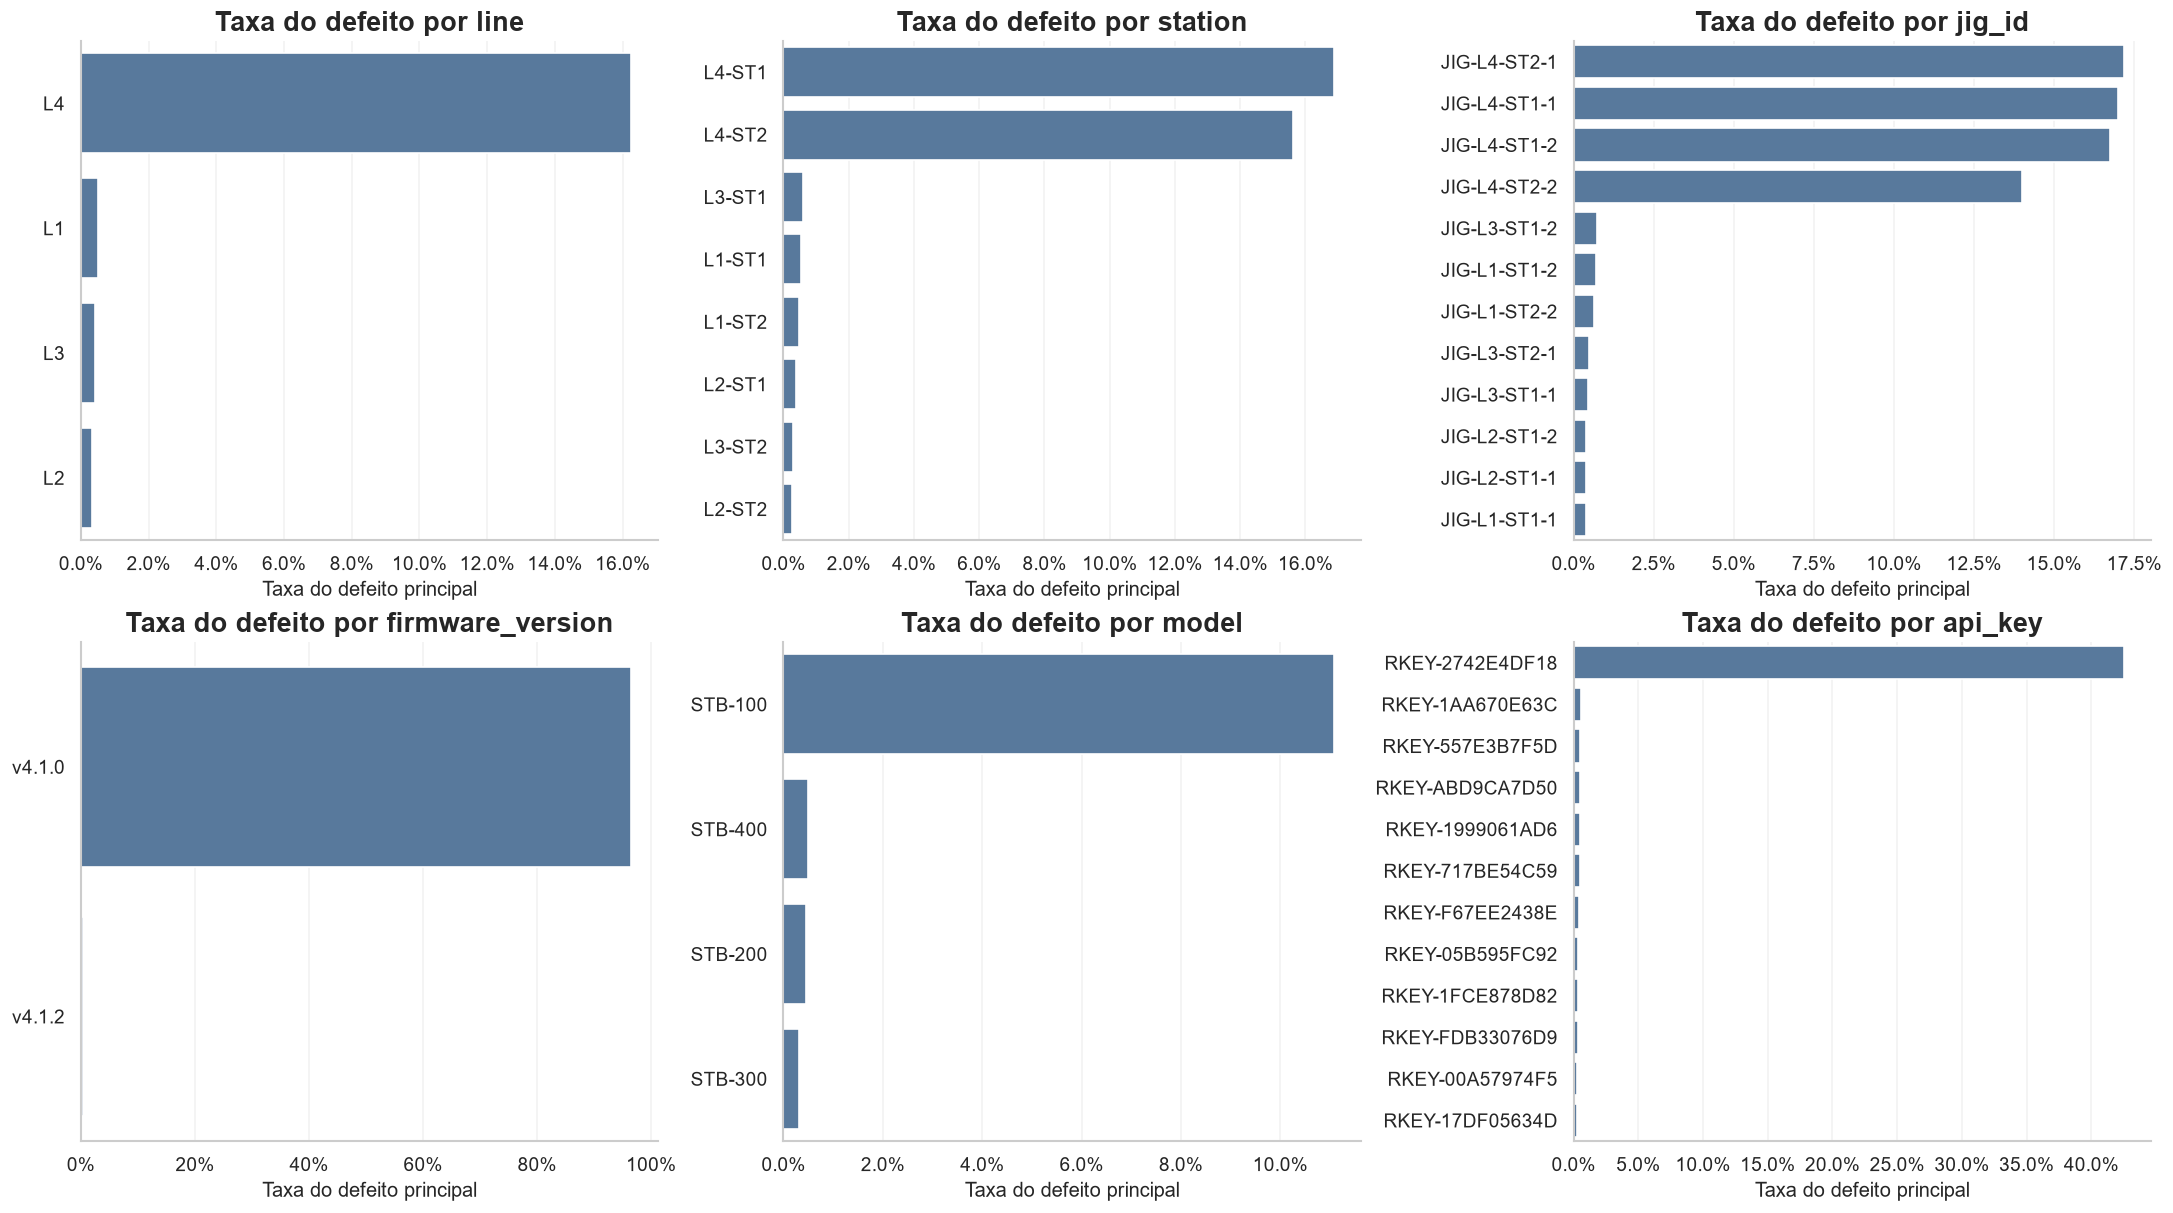

In [93]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()

for ax, dimension in zip(axes, where_dimensions):
    summary = where_summaries[dimension].head(12).copy()

    sns.barplot(
        data=summary,
        x="main_defect_rate",
        y=dimension,
        ax=ax,
        color="#4C78A8",
    )
    ax.set_title(f"Taxa do defeito por {dimension}")
    ax.set_xlabel("Taxa do defeito principal")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))

plt.show()

## PPM do defeito principal por linha e jig

PPM = defeitos / tentativas * 1.000.000. Aqui o PPM esta no nivel do defeito principal, nao no nivel de todos os defeitos.

In [94]:
ppm_line = where_summaries["line"][["line", "total_attempts", "main_defects", "main_defect_rate", "ppm_main_defect"]]
ppm_jig = where_summaries["jig_id"][["jig_id", "total_attempts", "main_defects", "main_defect_rate", "ppm_main_defect"]]

ppm_line_display = ppm_line.copy()
ppm_line_display["main_defect_rate"] = ppm_line_display["main_defect_rate"].map("{:.2%}".format)
ppm_line_display["ppm_main_defect"] = ppm_line_display["ppm_main_defect"].map("{:,.0f}".format)

ppm_jig_display = ppm_jig.copy()
ppm_jig_display["main_defect_rate"] = ppm_jig_display["main_defect_rate"].map("{:.2%}".format)
ppm_jig_display["ppm_main_defect"] = ppm_jig_display["ppm_main_defect"].map("{:,.0f}".format)

display(ppm_line_display)
display(ppm_jig_display.head(12))

,line,total_attempts,main_defects,main_defect_rate,ppm_main_defect
3,L4,3755,610,16.25%,"162,450"
0,L1,5141,26,0.51%,"5,057"
2,L3,3794,16,0.42%,"4,217"
1,L2,5154,17,0.33%,"3,298"


,jig_id,total_attempts,main_defects,main_defect_rate,ppm_main_defect
14,JIG-L4-ST2-1,961,165,17.17%,"171,696"
12,JIG-L4-ST1-1,948,161,16.98%,"169,831"
13,JIG-L4-ST1-2,932,156,16.74%,"167,382"
15,JIG-L4-ST2-2,914,128,14.00%,"140,044"
9,JIG-L3-ST1-2,806,6,0.74%,"7,444"
1,JIG-L1-ST1-2,1274,9,0.71%,"7,064"
3,JIG-L1-ST2-2,1274,8,0.63%,"6,279"
10,JIG-L3-ST2-1,1069,5,0.47%,"4,677"
8,JIG-L3-ST1-1,870,4,0.46%,"4,598"
5,JIG-L2-ST1-2,1242,5,0.40%,"4,026"


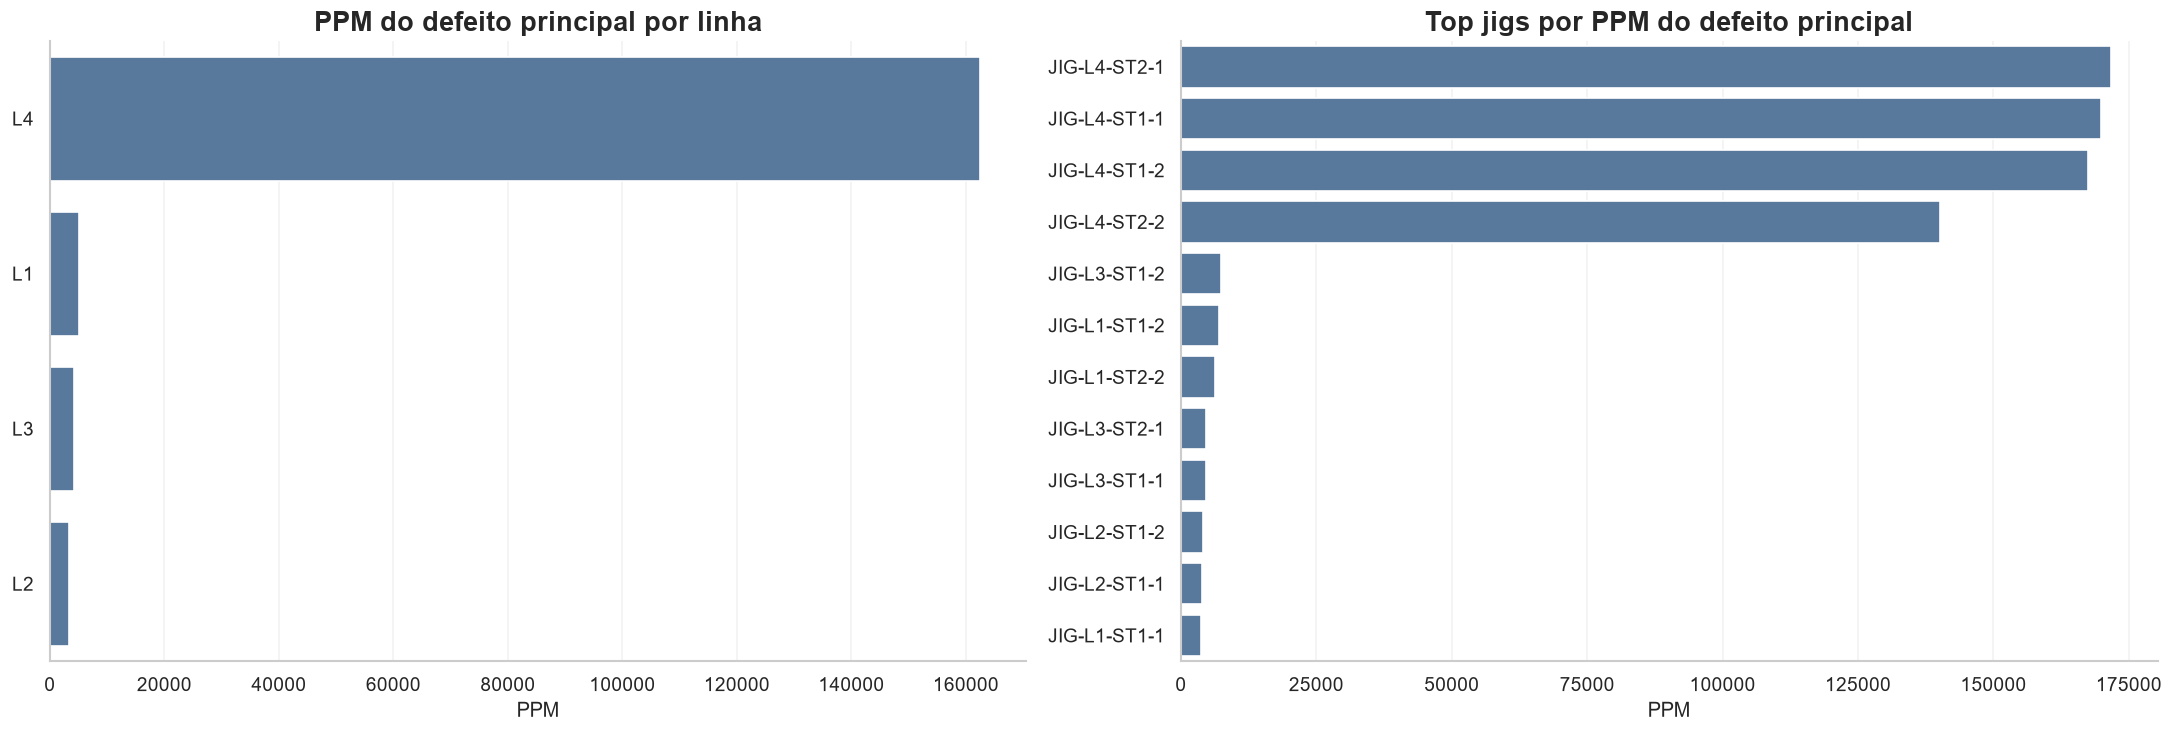

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.barplot(
    data=ppm_line,
    x="ppm_main_defect",
    y="line",
    ax=axes[0],
    color="#4C78A8",
)
axes[0].set_title("PPM do defeito principal por linha")
axes[0].set_xlabel("PPM")
axes[0].set_ylabel("")

sns.barplot(
    data=ppm_jig.head(12),
    x="ppm_main_defect",
    y="jig_id",
    ax=axes[1],
    color="#4C78A8",
)
axes[1].set_title("Top jigs por PPM do defeito principal")
axes[1].set_xlabel("PPM")
axes[1].set_ylabel("")

plt.show()

O PPM por linha e jig confirma que o defeito principal está altamente concentrado na L4. Os quatro jigs da L4 apresentam PPM muito superior aos demais, indicando uma causa sistêmica da linha ou do lote/configuração usada nela, e não uma falha isolada de equipamento.

## Quando o defeito principal aconteceu

A serie temporal abaixo usa janelas de 30 minutos. A linha mais escura e a media movel de 3 janelas, usada para reduzir ruido e deixar mais claro quando o problema comeca ou se intensifica.

In [96]:
time_summary = (
    analysis_df
    .set_index("timestamp")
    .groupby(pd.Grouper(freq="30min"))
    .agg(
        total_attempts=("result", "size"),
        total_failures=("is_fail", "sum"),
        main_defects=("is_main_defect", "sum"),
    )
    .query("total_attempts > 0")
    .reset_index()
)

time_summary["main_defect_rate"] = time_summary["main_defects"] / time_summary["total_attempts"]
time_summary["failure_rate"] = time_summary["total_failures"] / time_summary["total_attempts"]
time_summary["main_defect_rate_ma3"] = time_summary["main_defect_rate"].rolling(3, min_periods=1).mean()

display(
    time_summary.sort_values("main_defect_rate", ascending=False)
    .head(12)
    .assign(
        main_defect_rate=lambda df: df["main_defect_rate"].map("{:.2%}".format),
        failure_rate=lambda df: df["failure_rate"].map("{:.2%}".format),
        main_defect_rate_ma3=lambda df: df["main_defect_rate_ma3"].map("{:.2%}".format),
    )
)

,timestamp,total_attempts,total_failures,main_defects,main_defect_rate,failure_rate,main_defect_rate_ma3
32,2022-09-12 22:00:00,25,16,13,52.00%,64.00%,27.35%
34,2022-09-12 23:00:00,13,5,3,23.08%,38.46%,28.73%
31,2022-09-12 21:30:00,160,40,25,15.62%,25.00%,13.19%
30,2022-09-12 21:00:00,194,39,28,14.43%,20.10%,12.31%
6,2022-09-12 09:00:00,181,33,24,13.26%,18.23%,12.11%
28,2022-09-12 20:00:00,177,35,23,12.99%,19.77%,11.90%
26,2022-09-12 19:00:00,194,43,25,12.89%,22.16%,11.08%
24,2022-09-12 18:00:00,206,41,26,12.62%,19.90%,10.86%
4,2022-09-12 08:00:00,176,37,22,12.50%,21.02%,10.18%
9,2022-09-12 10:30:00,214,41,25,11.68%,19.16%,10.80%


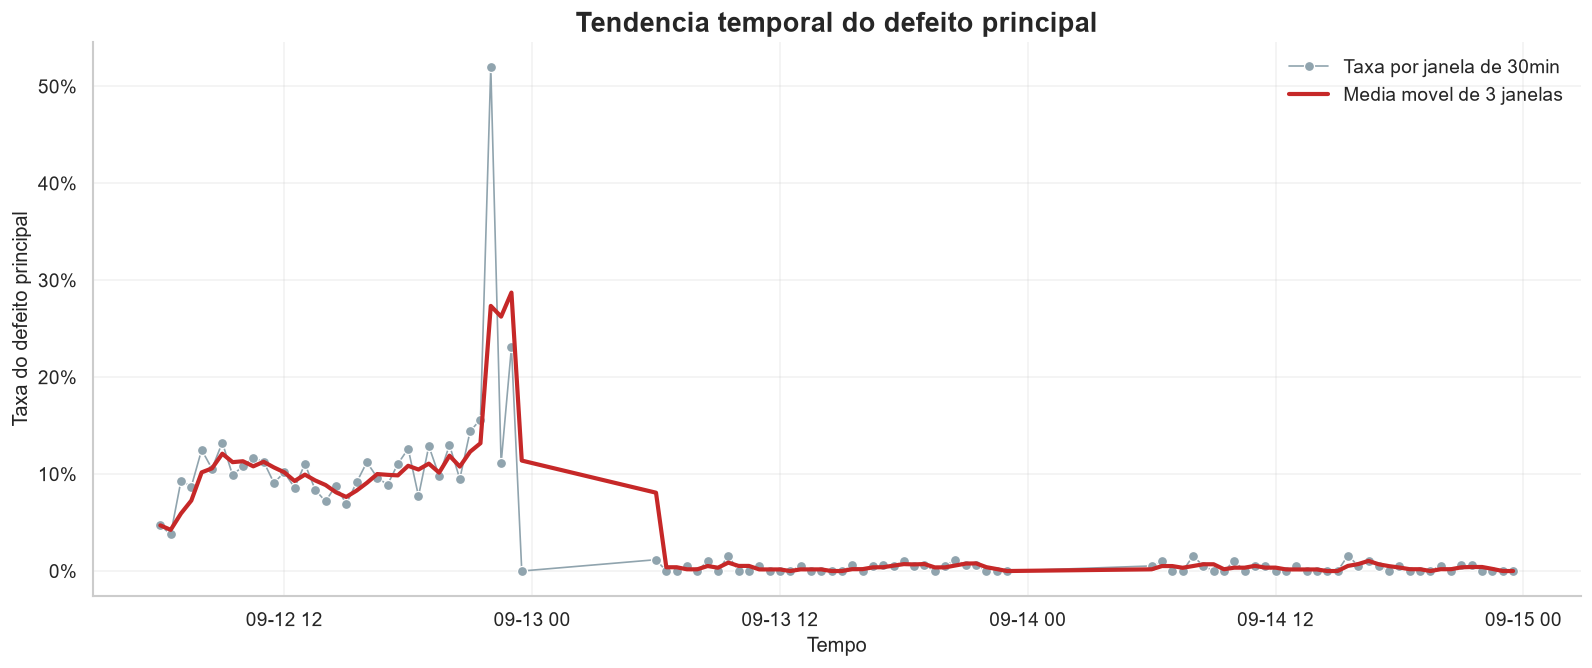

In [97]:
fig, ax = plt.subplots(figsize=(16, 6))

sns.lineplot(
    data=time_summary,
    x="timestamp",
    y="main_defect_rate",
    ax=ax,
    color="#90A4AE",
    marker="o",
    linewidth=1,
    label="Taxa por janela de 30min",
)

sns.lineplot(
    data=time_summary,
    x="timestamp",
    y="main_defect_rate_ma3",
    ax=ax,
    color="#C62828",
    linewidth=2.5,
    label="Media movel de 3 janelas",
)

ax.set_title("Tendencia temporal do defeito principal")
ax.set_xlabel("Tempo")
ax.set_ylabel("Taxa do defeito principal")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.legend(loc="upper right")

plt.show()

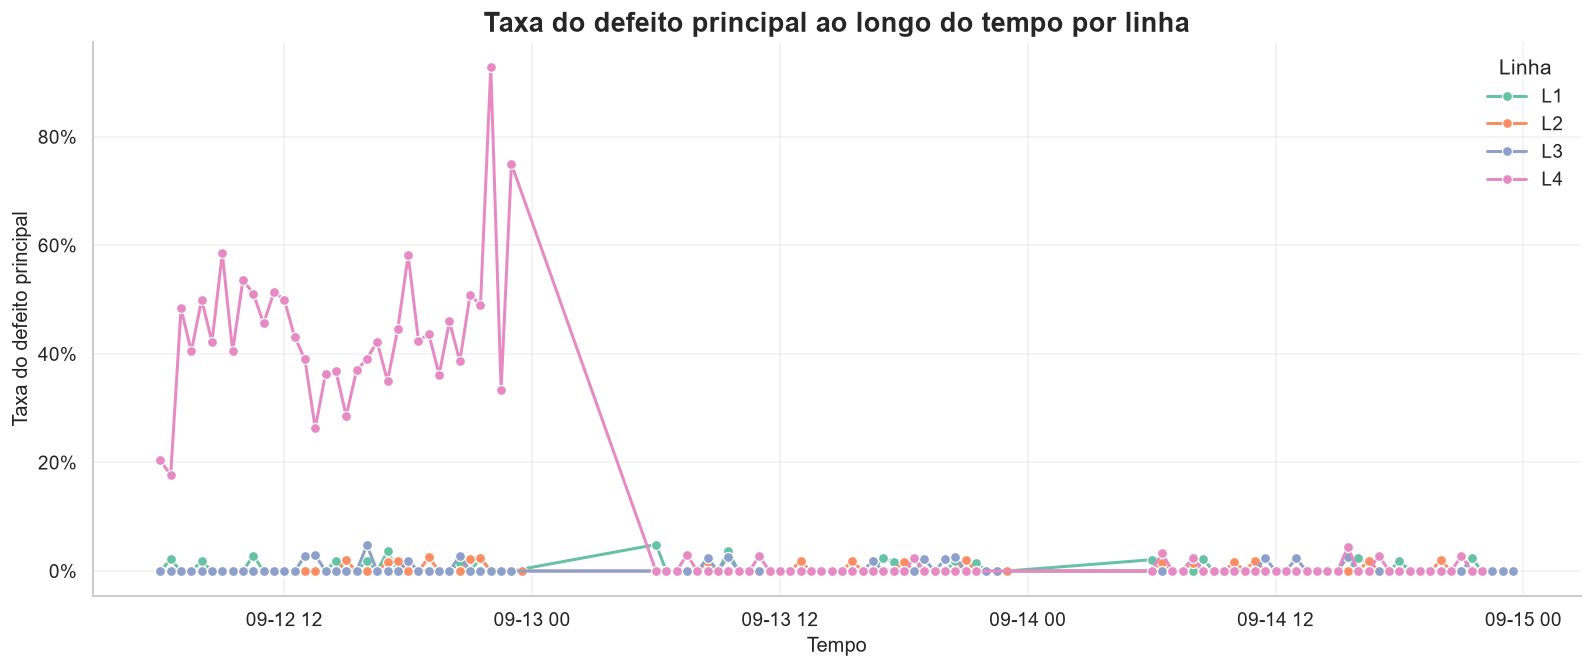

In [98]:
line_time_summary = (
    analysis_df
    .set_index("timestamp")
    .groupby(["line", pd.Grouper(freq="30min")])
    .agg(
        total_attempts=("result", "size"),
        main_defects=("is_main_defect", "sum"),
    )
    .query("total_attempts > 0")
    .reset_index()
)

line_time_summary["main_defect_rate"] = line_time_summary["main_defects"] / line_time_summary["total_attempts"]

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(
    data=line_time_summary,
    x="timestamp",
    y="main_defect_rate",
    hue="line",
    marker="o",
    linewidth=1.8,
    ax=ax,
)

ax.set_title("Taxa do defeito principal ao longo do tempo por linha")
ax.set_xlabel("Tempo")
ax.set_ylabel("Taxa do defeito principal")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.legend(title="Linha", loc="upper right")

plt.show()

O defeito drm_keys / ERR_DRM ocorreu de forma sistemática na L4 durante o dia 2022-09-12, desde o início da produção até o fim do turno/noite. Após 2022-09-13, o problema deixa de ser recorrente e passa a aparecer apenas como ruído isolado. Isso reforça a hipótese de um lote/configuração específico usado na L4 naquele dia, provavelmente ligado ao firmware v4.1.0, modelo STB-100 e API key RKEY-2742E4DF18.